# 実行例4.1 : アヤメデータの散布図（p.40 図4.2(a)）

- `Pkg.activate(@__DIR__)` : このファイルがあるフォルダの環境を有効化する。
- `Statistics` : 統計関数（mean(), var(), cov()など）
- `LinearAlgebra` :  線形代数（inv(), logdet()など）
- `DataFrames` : データフレーム（DataFrame()など）
- `CairoMakie` : 可視化バックエンド（マーカーをアルファベットにする）
- `Plots, StatsPlots`および`gr()` : 可視化ツール（`CairoMakie`とコンフリクトするので使用しない）

In [1]:
using Pkg
Pkg.activate(@__DIR__)
using Statistics
using LinearAlgebra
using DataFrames
using CairoMakie
# using Plots, StatsPlots
# gr()

  Activating project at `c:\Users\salt_\OneDrive\Documents\!勉強\Julia\Pattern_recognition`


### 1. 学習データの読み込み

In [2]:
# (1)iris.csvのファイルパスを設定する
filepath = joinpath(@__DIR__, "iris.csv")

# (2)iris.csv（filepath）を読み出す
lines = open(filepath, "r") do io
    # Iterators. : イテレータを操作するためのモジュール(この後ろに操作を示す関数が続く)
    # eachline(io) : ファイルioから1行ずつ読み出すイテレータ
    # Iterators.drop(eachline(io), 1) : タイトル行を削除する
    # |> : パイプライン
    # collect : 値やキーを配列にする関数
    Iterators.drop(eachline(io), 1) |> collect
end

# (3)データ配列の準備
sepal_length = Float64[]    # がく片の長さ
sepal_width = Float64[]     # がく片の幅
petal_length = Float64[]    # 花弁の長さ
petal_width = Float64[]     # 花弁の幅
Species = String[]          # 種別

# (4)読み出した行をカンマ区切りのデータ配列にする
for line in lines
    # iris.csvの順番でデータを変数に変換
    # 変数名はタイトル行のママ
    # strip : 両端の空白を削除（今回は不要）
    rownames, sepal_length_x, sepal_width_x, petal_length_x, petal_width_x, species_x = split(line, ",")

    # 配列に挿入
    push!(sepal_length, parse(Float64, sepal_length_x))
    push!(sepal_width, parse(Float64, sepal_width_x))
    push!(petal_length, parse(Float64, petal_length_x))
    push!(petal_width, parse(Float64, petal_width_x))
    push!(Species, strip(species_x))  # 両端の空白を削除してから挿入
end

### 2. 学習データのプロット

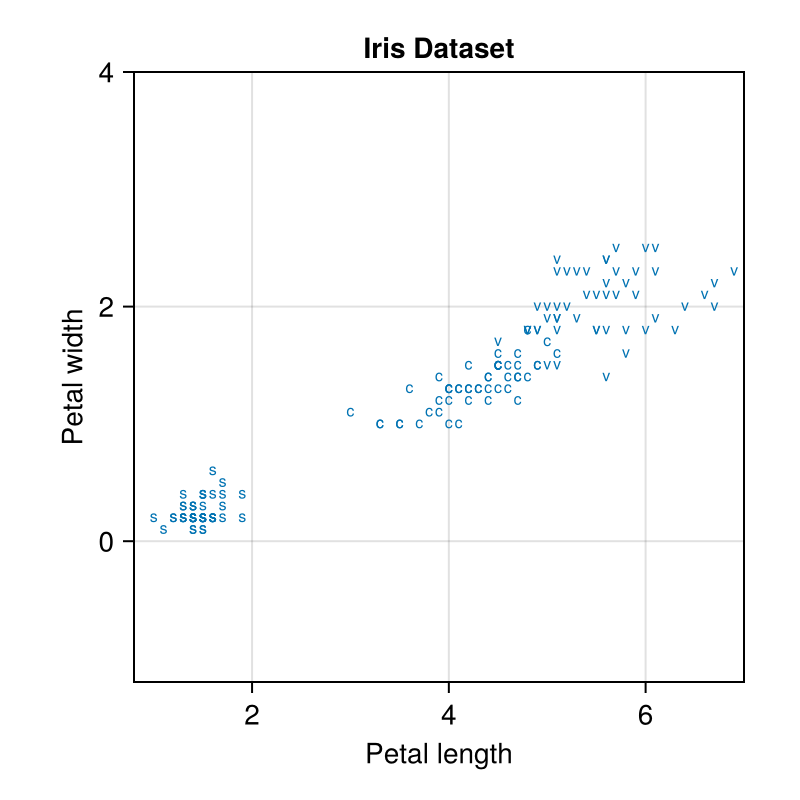

In [3]:
# scatter : 散布図のプロット
# 品種に分けてプロットするマークを区別する
# マーカーをアルファベットにするためCairoMakieとFrameworksを使用する
# using CairoMakie
# using Frameworks
# ⚠CarioMakieを使う場合はPlotsは使用しない

# ---(1) 品種別のマークの配列を準備---
# setosa : s
# versicolor : c
# virginica : v
# マークにアルファベットを指定する場合は''（Char型）を使う（""(String型)ではエラーになる）
# (A)三項演算子
# markers = [s == "setosa" ? 's' : s == "versicolor" ? 'c' : 'v' for s in Species]
# markers = [s == "setosa" ?  's' : s == "versicolor" ? 'c' : s == "virginica" ? 'v' : '?' for s in Species]
# (B)辞書（汎用性が高い）
marker_dict = Dict(
    "setosa" => 's', 
    "versicolor" => 'c', 
    "virginica" => 'v')
markers = [marker_dict[s] for s in Species]
# (C)関数（汎用性が高い）
# function get_marker(species)
#     if species == "setosa"
#         return 's'
#     elseif species == "versicolor"
#         return 'c'
#     elseif species == "virginica"
#         return 'v'
#     else
#         return '?'
#     end
# end
# markers = [get_marker(s) for s in Species]


# ---(2) マークを区別してプロット---
# ⚠CairoMakieを使う場合のscatterはPlotsと引数が異なる
# 以下の書き方だとエラーになる
# scatter(sepal_length, sepal_width,
# xlabel="sepal_length",
# ylabel="sepal_width",
# markers=markers,
# markersize=8,
# label=false,    # 凡例を表示しない
# title="Iris Dataset",
# size=(600,600), # 描画サイズを指定
# aspect_ratio=:auto # アスペクト比を自動（auto）に指定
# )

# ---① キャンバス`fig`、軸`ax`、プロット`plt`を準備---
fig = Figure(size = (400, 400))
ax = Axis(fig[1, 1])
plt = scatter!(ax, petal_length, petal_width,
marker=markers,
markersize=8)
# plt =  scatter!(ax, sepal_length, sepal_width,
# marker=markers,
# markersize=8)
# ---② 軸ラベル、タイトル、サイズ、アスペクト比を設定---
ax.xlabel = "Petal length"
ax.ylabel = "Petal width"
# ax.xlabel = "Sepal length"
# ax.ylabel = "Sepal width"
ax.title = "Iris Dataset"
ax.aspect = 1 # アスペクト比を正方形に指定
#ax.aspect = DataAspect() # アスペクト比をデータに合わせる
xlims!(ax, 0.8, 7.0)   # 横軸（x軸）の範囲
ylims!(ax, -1.2, 4.0)  # 縦軸（y軸）の範囲
# ---③ プロットの保存と表示---
save("iris_scatter.png", fig)   # 保存
fig # 表示